# Toy example to check KL div loss

In [1]:
import numpy as np
import torch
from sklearn.cluster import KMeans
from torch.nn import KLDivLoss
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE
import wandb

from nnfabrik.utility.nn_helpers import set_random_seed


seed = 42
set_random_seed(seed)
torch.cuda.is_available()
cuda_number = 5
#torch.cuda.set_device(f"cuda:{cuda_number}")
#device = f'cuda:{cuda_number}'
device = 'cpu'

In [2]:
cluster_number=2
dec_starting_epoch=30
alpha=1.0
kmeans_init=20
base_multiplier=4e3
exponent=1.2
data_spread = 5

In [3]:
from sklearn.datasets import make_blobs

# Generate a 5D dataset with two clusters
n_samples = 2000
n_features = 4
n_clusters = cluster_number
X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_clusters, random_state=42)
max_abs = 10  # Example threshold
X = X / np.max(np.abs(X), axis=0) 

# Print shape to verify
print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (2000, 4)
Labels shape: (2000,)


In [4]:
class LinearFunction:
    def __init__(self, func, weight, shift):
        self.func = func
        self.weight = weight
        self.shift = shift
        self.vector = np.array([weight, shift])

    def __call__(self, X):
        return self.func(X)

def generate_functions(sample_size, seed=42):
    np.random.seed(seed)  # Set the seed for reproducibility
    functions = []

    # Cluster 1: Small variations (close to np.sum(X, axis=1))
    for i in range(sample_size):
        shift = np.random.uniform(0, 0.001)  # Tiny shifts
        functions.append(lambda X, s=shift: np.sum(X, axis=1) + s)

    # Cluster 2: Large shifts (well-separated from cluster 1)
    for i in range(int(sample_size / 4)):
        shift = np.random.uniform(0, 0.005)  # Large shifts
        functions.append(lambda X, s=shift: 1.5 * np.sum(X, axis=1) + s)

    return functions

# Apply functions
def apply_functions(X, sample_size, seed=42):
    functions = generate_functions(sample_size, seed=seed)
    return np.column_stack([f(X) for f in functions]), functions

'''
def apply_functions(X, sample_size, seed=42):
    raw_funcs = generate_functions(sample_size, seed=seed)
    wrapped_funcs = []

    for f in raw_funcs:
        # extract shift and weight from function string
        source = f.__code__.co_consts
        shift = source[-1]  # shift value
        weight = 1.5 if '1.5' in f.__code__.co_names else 1.0  # crude check

        wrapped_funcs.append(LinearFunction(f, weight, shift))

    labels = np.column_stack([f(X) for f in wrapped_funcs])
    return labels, wrapped_funcs
'''

"\ndef apply_functions(X, sample_size, seed=42):\n    raw_funcs = generate_functions(sample_size, seed=seed)\n    wrapped_funcs = []\n\n    for f in raw_funcs:\n        # extract shift and weight from function string\n        source = f.__code__.co_consts\n        shift = source[-1]  # shift value\n        weight = 1.5 if '1.5' in f.__code__.co_names else 1.0  # crude check\n\n        wrapped_funcs.append(LinearFunction(f, weight, shift))\n\n    labels = np.column_stack([f(X) for f in wrapped_funcs])\n    return labels, wrapped_funcs\n"

Visualisation using kmeans

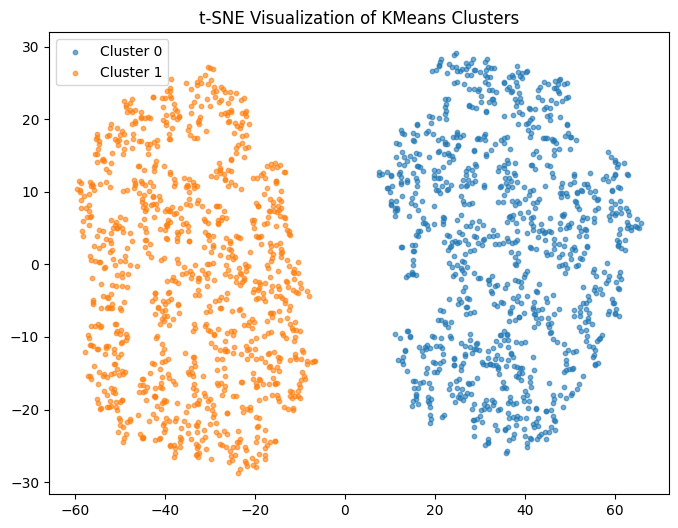

In [5]:
def kmeans_clustering(features, n_clusters=10):
    """Performs KMeans clustering on extracted features."""
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    predictions = kmeans.fit_predict(features)
    return kmeans, predictions

def visualize_tsne(features, predictions, n_clusters=10):
    """Performs t-SNE and visualizes clusters."""
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    reduced_features = tsne.fit_transform(features)

    plt.figure(figsize=(8, 6))
    for i in range(n_clusters):
        plt.scatter(
            reduced_features[predictions == i, 0], reduced_features[predictions == i, 1], 
            label=f'Cluster {i}', alpha=0.6, s=10,
        )
    
    plt.legend()
    plt.title("t-SNE Visualization of KMeans Clusters")
    plt.show()

def main(data, labels, n_clusters=10, device="cuda"):
    kmeans, predictions = kmeans_clustering(data, n_clusters)
    visualize_tsne(data, predictions, n_clusters)
    

main(X, y, n_clusters=2)

In [6]:
# create dataset
class ClusteredDataset(Dataset):
    def __init__(self, cluster_number=cluster_number, n_features=n_features, n_samples=n_samples, feature_size=1000, seed=42):
        np.random.seed(seed)

        X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=cluster_number, random_state=seed)
        np.save("data_toy.npy", X)
        
        labels, functions = apply_functions(X, feature_size)
        np.save('toy_labels.npy', labels)
        # Print shape to verify
        print("Feature matrix shape:", X.shape)
        print("Labels shape:", labels.shape)

        self.data = torch.tensor(X, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float)
        self.functions =functions

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Function to load the dataset
def load_dataset(batch_size=128, cluster_number=2,n_features=4,n_samples=2000, feature_size=2000):
    dataset = ClusteredDataset(cluster_number=cluster_number, n_features=n_features, n_samples=n_samples,feature_size=feature_size)
    
    return DataLoader(dataset, batch_size=batch_size, shuffle=True), dataset

In [7]:
# simple linear model
import torch.nn as nn
class SimpleNN(nn.Module):
    def __init__(self, input_dim, output_dim=500):
        super(SimpleNN, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)  # Directly define the layer

    def forward(self, x):
        return self.linear(x)  # No need for Sequential

In [8]:
def update_alpha(resp, u, alpha, max_iter=10, tol=1e-4):
    'updates alpha when maximizing the log likelihood with newton method'
    for _ in range(max_iter):
        f_alpha = -torch.sum(
                resp * (1 + (torch.log(u) - u) + torch.special.digamma(alpha / 2) - torch.log(alpha/ 2))
            )
        f_prime_alpha = (1 / alpha) - (0.5 * torch.special.polygamma(1, alpha / 2))  # Trigamma function

        alpha_new = alpha - f_alpha / f_prime_alpha  # Newton-Raphson update

        # Ensure alpha stays in a valid range
        alpha_new = torch.clamp(alpha_new, min=0.01, max=100)

        if torch.abs(alpha_new - alpha) < tol:
            break

        alpha = alpha_new.detach()
    return alpha

In [9]:
def soft_assignments_mult(encoded_features, cluster_centers, sigma, alpha=1, p=1):
    sigma_inv = 1.0 / sigma  # (K, D)
    #print('sigma inv', sigma_inv)
    #print("NaNs in encoded_features:", torch.isnan(encoded_features).any())
    #print("NaNs in cluster_centers:", torch.isnan(cluster_centers).any())
    assert not torch.isnan(encoded_features).any(), "NaNs in encoded_features:"
    assert not torch.isnan(cluster_centers).any(), "NaNs in cluster_centers:"
    assert not torch.isinf(encoded_features).any(),"isinf in encoded_features:"
    assert not torch.isinf(cluster_centers).any(), "isinf in cluster_centers:"
    diff = encoded_features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)  # (N, K, D)
    assert not torch.isnan(diff).any(), "NaNs in diff:"
    assert not torch.isinf(diff).any(), "isinf in diff:"
    # print(diff)
    norm_sigma = torch.sum(diff * sigma_inv*diff, dim=2)  # (N, K)
    # print('Norm sigma', norm_sigma)
    assert not torch.isnan(norm_sigma).any(), "NaNs in norm_sigma:"
    assert not torch.isinf(norm_sigma).any(), "isinf in norm_sigma:"
    det = torch.sum(torch.log(sigma), dim=1)  # log(det) since sigma is diagonal

    # Log Gamma terms
    log_gamma_top = torch.lgamma((alpha + p) / 2)
    log_gamma_bottom = torch.lgamma(alpha / 2)

    # Log-density formula for multivariate Student-t
    log_pdf = (
        log_gamma_top - log_gamma_bottom
        - 0.5 * det
        - (p / 2) * torch.log(alpha * torch.pi)
        - ((alpha + p) / 2) * torch.log(1 + (norm_sigma / alpha))
    )

    assert not torch.isnan(log_pdf).any(), "NaNs in log_pdf:"
    assert not torch.isinf(log_pdf).any(), "isinf in log_pdf:"

    # print('log pdf' , log_pdf)
    # print('exp(log) pdf', torch.exp(log_pdf))
    #log_assignments = log_pdf - torch.logsumexp(log_pdf, dim=1, keepdim=True)
    log_pdf_max = torch.max(log_pdf, dim=1, keepdim=True)[0]  # Get max per row

    assert not torch.isnan(log_pdf_max).any(), "NaNs in log_pdf_max"
    assert not torch.isinf(log_pdf_max).any(), "isinf in log_pdf_max"

    assert not torch.isnan(
        torch.logsumexp(log_pdf - log_pdf_max, dim=1, keepdim=True)
        ).any(), "NaNs in logsumexp bracets"
    assert not torch.isinf(
        torch.logsumexp(log_pdf - log_pdf_max, dim=1, keepdim=True)
    ).any(), "isinf in logsumexp bracets"

    log_assignments = log_pdf - torch.logsumexp(log_pdf , dim=1, keepdim=True)
    # print('log assignmnents ', log_assignments)
    assert not torch.isnan(log_assignments).any(), "NaNs in log_assignments:"
    assert not torch.isinf(log_assignments).any(), "isinf in log_assignments:"

    assert not torch.isnan(torch.exp(log_assignments)).any(), "NaNs in torch.exp(log_pdf):"
    assert not torch.isinf(torch.exp(log_assignments)).any(), "isinf in torch.exp(log_pdf):"


    return torch.exp(log_assignments)  # Convert log-assignments to probabilities
    


def target_distribution(batch: torch.Tensor, exponent=exponent) -> torch.Tensor:
    weight = (batch**exponent) / torch.sum(batch, 0)
    return (weight.t() / torch.sum(weight, 1)).t()

def EM_t_mult(features, resp, cluster_centers, sigma, alpha, d=1):
    sigma_inv = 1.0 / sigma  # (K,)
    diff = (features.T.unsqueeze(1) - cluster_centers.unsqueeze(0))
    norm_sigma = torch.sum((diff **2 * sigma_inv),2)  
    u = ((alpha + d)/(alpha +norm_sigma)).detach()  #ccalculate U shape(N,K)
    #print('u', u.shape)
    #print(resp.shape)
    
    ''' M step '''
    numerator = torch.matmul(features,resp*u).T.detach()
    #print(numerator.shape)
    denominator = torch.sum(resp*u, dim=0, keepdim=True).T.detach()
    #print(denominator.shape)
    cluster_centers = numerator/denominator

    weighted_sq_diff = resp.unsqueeze(2)* u.unsqueeze(2) * (diff ** 2)  # (N, K, D)
    numerator = weighted_sq_diff.sum(dim=0) #(K,D)
    denominator = torch.sum(resp, dim=0, keepdim=True)  # (K,)
    #print('sigma de', denominator.shape)
    sigma = (numerator / denominator.T).detach() 
    
    #sigma = torch.clamp(sigma, min=1e-4, max=1e4)

    return cluster_centers, sigma

In [10]:
def EM_t_1D(features, resp, cluster_centers, taus, alpha, d=1):
    norm_squared = torch.sum(
    (features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)) ** 2, dim=2
    )  
    u = (alpha + d)/(alpha +norm_squared*(taus**(-1)))  #ccalculate U shape(N,K)
    print('u', u.shape)
    print(resp.shape)
    ''' M step '''
    numerator = torch.matmul(features,resp*u).T.detach()
    print(numerator.shape)
    denominator = torch.sum(resp*u, dim=0, keepdim=True).T.detach()
    print(denominator.shape)
    cluster_centers = numerator/denominator

    weighted_sums = torch.sum(resp* u * norm_squared, dim=0) 
    #print('WS', weighted_sums.shape)
    taus = (weighted_sums / torch.sum(resp, dim=0, keepdim=True)).detach()
    #print('Tau', taus.shape)
    return cluster_centers, taus


def soft_assignments_1D(encoded_features, cluster_centers, tau, alpha=1, p=1):
    norm_squared = torch.sum(
        (encoded_features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)) ** 2, 2
    )
    assignments = 1.0 / (1.0 + (norm_squared / (alpha * tau)))
    assignments = (assignments ** ((alpha + p) / 2))/(tau**1/2)
    #print('Assignments shape', assignments.shape)
    return assignments / torch.sum(assignments, dim=1, keepdim=True)

In [11]:
def trainer(model, dataloader, cluster_number=cluster_number, kmeans_init=10, 
            dec_starting_epoch=dec_starting_epoch,
            use_wandb = True,
            use_diag_cov=True,
            learn_alpha=True,
            log_likelihood_alpha=False,
            exponent=exponent, lr=0.008, epochs=100, device=device, alpha = 1.0):
    '''
    use_diag_conv: Bool that indicates wether to use a diagonal covariance matrix or just one value for each cluster
    '''
    if learn_alpha:
        alpha = torch.nn.Parameter(torch.tensor(1.0, device=device, requires_grad=True))
        optimizer = torch.optim.Adam(list(model.parameters()) + [alpha], lr=lr)
    else:
        alpha = torch.tensor(alpha, device=device, requires_grad=False)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    kldiv_criterion = KLDivLoss(
        size_average=False
    )  # losses are summed for each minibatch
    criterion = nn.MSELoss()
    def repulsion_loss(cluster_centers, epsilon=1e-6):
        'Regularization term that penalizes small distances between clusters'
        pairwise_distances = torch.cdist(cluster_centers, cluster_centers, p=2)  # Compute pairwise distances
        pairwise_distances = torch.triu(pairwise_distances, diagonal=1)  # Keep only upper triangle (ignores diagonal)
        return torch.sum(1.0 / (pairwise_distances + epsilon)) 
    if use_wandb:
        wandb.init(
            project='Toy example',
            entity='ninasophie-nellen-g-ttingen-university',
            name='toy run higher dimensoinal epsilon 1, EM',
            config={
                "learning_rate": lr,
                "cur_epochs": epochs,
            },
        )
        wandb.run.log_code(".")
        # metrics represent any value I want to track, if they're hidden, they're not displayed on default cisualisation
        wandb.define_metric(name="Epoch", hidden=True)
        wandb.define_metric(name="Batch", hidden=True)

    model.to(device)
    model.train()
    for epoch in range(epochs):

        epoch_loss = 0
        epoch_kldiv_loss = 0
        epoch_loss_main = 0
        '''
        if epoch >= 50:
            lr = 0.0005
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        '''
        if epoch == dec_starting_epoch:
            cluster_centers_list = []
            features = model.linear.weight.data.detach().cpu().numpy()
            print(features.shape)
            kmeans = KMeans(
                n_clusters=cluster_number, n_init=kmeans_init, random_state=seed
            )
            with torch.no_grad():
                predicted = kmeans.fit_predict(features)

            cluster_centers = torch.tensor(
                kmeans.cluster_centers_, dtype=torch.float, device=device, requires_grad=True,
            )
            print('cluster centers', cluster_centers)
            if use_diag_cov:
                p = features.shape[1]
                sigma = torch.zeros((cluster_number,p), device=device)
                for k in range(cluster_number):
                    cluster_points = torch.from_numpy(features[predicted == k]).to(device) 
                    if len(cluster_points) > 0:
                        sigma[k] = torch.var(cluster_points, dim=0, unbiased=True) +1e-6

            else: 
                sigma = torch.zeros(cluster_number, device=device)
                for k in range(cluster_number):
                    cluster_points = torch.from_numpy(features[predicted == k]).to(device)  
                    if len(cluster_points) > 0:
                        sigma[k] = torch.mean(torch.sum((cluster_points - cluster_centers[k])**2,1))
                sigma = sigma.unsqueeze(0)
                print('Tau beginning', sigma)
                p=1
            print('p',p)
            if learn_alpha:
                alpha.data = torch.tensor(1.0, dtype=torch.float, device=device)

            with torch.no_grad():
                cluster_centers_list.append(cluster_centers.cpu().detach().numpy())
            
            tsne = TSNE(n_components=2, learning_rate=features.shape[0]/12, perplexity=30, random_state=42)
            reduced_features = tsne.fit_transform(features)

            plt.figure(figsize=(8, 6))
            plt.scatter(
                reduced_features[:, 0], reduced_features[:, 1], alpha=0.6, s=10,)
            plt.title("t-SNE Visualization of KMeans Clusters")
            plt.show()

        for i, (inputs, labels) in enumerate(dataloader): 
            #if epoch < dec_starting_epoch:
            inputs = inputs.to(device)     
            labels = labels.to(device) 
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward() 
            if epoch >= dec_starting_epoch:
                loss = torch.zeros(1, device=device)
            epoch_loss += loss.detach()
            epoch_loss_main += loss.detach() 
            if epoch >= dec_starting_epoch:
                features = model.linear.weight.T
                for name, param in model.named_parameters():
                    if param.grad is not None and torch.isnan(param.grad).any():
                        print(f"NaN in gradients of {name}")
                if use_diag_cov:
                    q = soft_assignments_mult(features, cluster_centers, sigma, alpha,p)
                else:
                    q = soft_assignments_1D(features, cluster_centers, sigma, alpha,p)

                q =q.clamp(min =1e-10)
                assert not torch.isnan(q).any(),  "NaNs in soft assignments:"
                assert not torch.isinf(q).any(), "Infs in soft assignments:"

                #print(f'q.min()={q.min()}, q.max()={q.max()}, zeros_in_q={(q == 0).any()}')

                target = target_distribution(q, exponent)
                # print('sigma', sigma)
                assert not torch.isnan(target).any(), "NaNs in target:"
                assert not torch.isinf(target).any(), "Infs in target:"
                #q = q.clamp(min=1e-10)
                target = target.clamp(min=1e-10)
                assert not torch.isnan(q.log()).any(),  "NaNs in soft assignments: .log()"
                assert not torch.isinf(q.log()).any(), "Infs in soft assignments: .log()"
                #print(f'after clamp - q.min()={q.min()}, q.max()={q.max()}, zeros_in_q={(q == 0).any()}')
                kldiv_loss =  kldiv_criterion(q.log(), target)
                assert not torch.isnan(kldiv_loss), 'KL loss isnan'
                assert not torch.isinf(kldiv_loss), 'KL loss isinf'
                #print('KL loss', kldiv_loss)
                
                target = target.clamp(min=1e-10)
                kldiv_loss.backward()
                for name, param in model.named_parameters():
                    if param.grad is not None and torch.isnan(param.grad).any():
                        print(f"NaN detected in gradients of {name}")
                #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
                epoch_kldiv_loss += kldiv_loss.detach()
                #print('KL loss', kldiv_loss)
                epoch_loss += kldiv_loss.detach()
                if use_diag_cov:
                    cluster_centers, sigma = EM_t_mult(features, q, cluster_centers, sigma, alpha, p)
                else:
                    cluster_centers, sigma = EM_t_1D(features, q, cluster_centers, sigma, alpha, p)
                with torch.no_grad():
                    cluster_centers_np = cluster_centers.cpu().detach().numpy()
                    cluster_centers_list.append(cluster_centers_np)
                #print('alpha', alpha)
                low_values_mask = (q < 1).all(dim=1)
                true_count = low_values_mask.sum()

                print('Q values where prob is not 1' , true_count) 
            optimizer.step()  
            optimizer.zero_grad()   
            #print(alpha)

        #print(f"Epoch {epoch}, loss: {loss}")
        if use_wandb:
            wandb_dict = {
                "Epoch Train loss": epoch_loss,
                "Epoch Train loss main": epoch_loss_main,
                "Epoch Train loss Kullback-Leibler-divergence": epoch_kldiv_loss,
            }
            wandb.log(wandb_dict)

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()
    print(cluster_centers)
    print("Training Complete!")
    model.eval()
    features = model.linear.weight.data.detach()
    if use_diag_cov:
        q = soft_assignments_mult(features.T, cluster_centers, sigma, alpha,p)
    else:
        q = soft_assignments_1D(features.T, cluster_centers, sigma, alpha,p)
    features = (features).cpu().numpy()
    predictions = (q).max(1)[1].cpu().numpy()
    cluster_centers_np = np.array(cluster_centers_list)

    return features, predictions, cluster_centers_np

In [12]:
def trainer_DEC(model, dataloader, cluster_number=cluster_number, kmeans_init=10, 
            dec_starting_epoch=dec_starting_epoch,
            use_wandb = True,
            use_diag_cov=True,
            learn_alpha=True,
            log_likelihood_alpha=False,
            exponent=exponent, lr=0.008, epochs=100, device=device, alpha = 1.0):
    '''
    use_diag_conv: Bool that indicates wether to use a diagonal covariance matrix or just one value for each cluster
    '''
    p = model.linear.in_features
    cluster_centers = torch.nn.Parameter(
        torch.zeros(
            cluster_number,
            p,
            dtype=torch.float,
            device=device,
        ),
        requires_grad=True,
    )  
    '''
    sigma = torch.nn.Parameter(
        torch.zeros(
            cluster_number,
            p,
            dtype=torch.float,
            device=device,
        ),
        requires_grad=True,
    )  
    '''
    if learn_alpha:
        alpha = torch.nn.Parameter(torch.tensor(1.0, device=device, requires_grad=True))
        optimizer = torch.optim.Adam(
            list(model.parameters())
            + [cluster_centers] + [alpha]+ [sigma],  # Combine model params and additional tensor
            lr=lr
            )
    else:
        alpha = torch.tensor(alpha, device=device, requires_grad=False)
        optimizer = torch.optim.AdamW(
            list(model.parameters())
            + [cluster_centers] ,  # Combine model params and additional tensor
            lr=lr,
            )
    kldiv_criterion = KLDivLoss(
        size_average=False
    )  # losses are summed for each minibatch
    criterion = nn.MSELoss()
    if use_wandb:
        wandb.init(
            project='Toy example',
            entity='ninasophie-nellen-g-ttingen-university',
            name='toy run higher dimensoinal epsilon 1, learned centers',
            config={
                "learning_rate": lr,
                "cur_epochs": epochs,
            },
        )
        wandb.run.log_code(".")
        # metrics represent any value I want to track, if they're hidden, they're not displayed on default cisualisation
        wandb.define_metric(name="Epoch", hidden=True)
        wandb.define_metric(name="Batch", hidden=True)

    model.to(device)
    model.train()

    prev_loss = float('inf')  # Initialize with a high value
    decreasing = True  # Track if loss was previously decreasing
    for epoch in range(epochs):

        epoch_loss = 0
        epoch_kldiv_loss = 0
        epoch_loss_main = 0
        '''
        if epoch >= 50:
            lr = 0.0005
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        '''
        if epoch == dec_starting_epoch:
            cluster_centers_list = []
            features = model.linear.weight.data.detach().cpu().numpy()
            #print(features.shape)
            kmeans = KMeans(
                n_clusters=cluster_number, n_init=kmeans_init, random_state=seed
            )
            with torch.no_grad():
                predicted = kmeans.fit_predict(features)

            cluster_centers.data = torch.tensor(
                kmeans.cluster_centers_, dtype=torch.float, device=device
            )
            print(cluster_centers)
            mixing_coefficient = torch.ones(cluster_number, device=device) / cluster_number 
            if use_diag_cov:
                for k in range(cluster_number):
                    cluster_points = torch.from_numpy(features[predicted == k]).to(device) 
                    if len(cluster_points) > 0:
                        sigma[k].data.copy_(torch.var(cluster_points, dim=0, unbiased=True) + 1e-6)

            else: 
                '''
                for k in range(cluster_number):
                    cluster_points = torch.from_numpy(features[predicted == k]).to(device)  
                    if len(cluster_points) > 0:
                        sigma[k].data.copy_(torch.var(cluster_points, dim=0, unbiased=True) + 1e-6)
                sigma = sigma.unsqueeze(0)'
                '''
                sigma=1
                p=1
            if learn_alpha:
                alpha.data = torch.tensor(1.0, dtype=torch.float, device=device)

            print('Sigma beginning', sigma)
            with torch.no_grad():
                cluster_centers_list.append(cluster_centers.cpu().detach().numpy())
            
            tsne = TSNE(n_components=2, learning_rate=features.shape[0]/12, perplexity=30, random_state=42)
            reduced_features = tsne.fit_transform(features)

            plt.figure(figsize=(8, 6))
            plt.scatter(
                reduced_features[:, 0], reduced_features[:, 1], alpha=0.6, s=10,)
            plt.title("t-SNE Visualization of KMeans Clusters")
            plt.show()

        for i, (inputs, labels) in enumerate(dataloader): 
            #if epoch < dec_starting_epoch:
            inputs = inputs.to(device)     
            labels = labels.to(device) 
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward() 
            if epoch >= dec_starting_epoch:
                loss = torch.zeros(1, device=device)
            epoch_loss += loss.detach()
            epoch_loss_main += loss.detach() 
            if epoch >= dec_starting_epoch:
                features = model.linear.weight.T

                if use_diag_cov:
                    q = soft_assignments_mult(features, cluster_centers, sigma, alpha,p)
                else:
                    q = soft_assignments_1D(features, cluster_centers, sigma, alpha,p)

                target = target_distribution(q, exponent)
                target = target.clamp(min=1e-10)
                q = q.clamp(min=1e-10)
                    
                kldiv_loss =  kldiv_criterion(q.log(), target)
                #print('KL loss', kldiv_loss)

                #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
                kldiv_loss.backward()

                epoch_kldiv_loss += kldiv_loss.detach()
                #print('KL loss', kldiv_loss)
                epoch_loss += kldiv_loss.detach()

                
                #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                #torch.nn.utils.clip_grad_norm_([cluster_centers, sigma], max_norm=5.0)
                #print('cluster centers', cluster_centers)
                with torch.no_grad():
                    cluster_centers_np = cluster_centers.cpu().detach().numpy()
                    cluster_centers_list.append(cluster_centers_np)
            optimizer.step()  
            optimizer.zero_grad()   
            #print(alpha)

        #print(f"Epoch {epoch}, loss: {loss}")
        if use_wandb:
            wandb_dict = {
                "Epoch Train loss": epoch_loss,
                "Epoch Train loss main": epoch_loss_main,
                "Epoch Train loss Kullback-Leibler-divergence": epoch_kldiv_loss,
            }
            wandb.log(wandb_dict)

    print(cluster_centers)
    print("Training Complete!")
    model.eval()
    features = model.linear.weight.data.detach()
    if use_diag_cov:
        q = soft_assignments_mult(features.T, cluster_centers, sigma, alpha,p)
    else:
        q = soft_assignments_1D(features.T, cluster_centers, sigma, alpha,p)
    features = (features).cpu().numpy()
    predictions = (q).max(1)[1].cpu().numpy()
    cluster_centers_np = np.array(cluster_centers_list)
    return features, predictions, cluster_centers_np

In [13]:
dataloader, dataset = load_dataset(batch_size=256, n_features=30, n_samples=8000, feature_size=2000)
functions = dataset.functions
model = SimpleNN(input_dim=30, output_dim=2500)
cluster_number=2

Feature matrix shape: (8000, 30)
Labels shape: (8000, 2500)


/user/ninasophie.nellen/anaconda3/envs/my_env/lib/python3.12/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


Parameter containing:
tensor([[ 0.7933,  0.1299,  0.4624,  0.4114,  0.5275,  0.5167,  0.4764,  0.2512,
          0.5496,  0.4059,  0.4834,  0.0698,  0.2836,  0.5560,  0.5601,  0.5204,
          0.6482,  0.9749,  0.9029,  0.6249,  0.3337,  0.5292,  0.6215,  0.7702,
          0.9369,  0.1085,  0.5688,  0.9888,  0.8858,  0.4836],
        [ 0.9419, -0.0420,  0.3199,  0.2579,  0.6135,  0.6137,  0.5869,  0.0737,
          0.4381,  0.2472,  0.5902, -0.0976,  0.1039,  0.6507,  0.6670,  0.6174,
          0.7586,  1.3606,  1.1307,  0.7347,  0.1613,  0.6292,  0.7242,  0.9405,
          1.2932, -0.0724,  0.6672,  1.3406,  1.1012,  0.5973]],
       requires_grad=True)
Sigma beginning 1


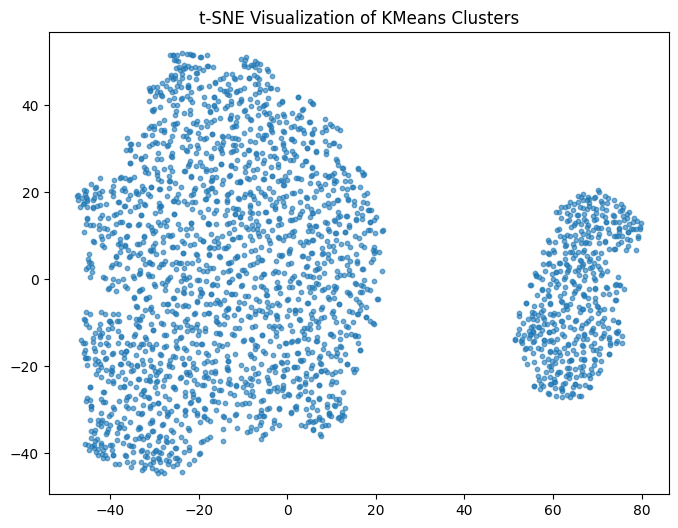

Parameter containing:
tensor([[ 0.7896,  0.0315,  0.3380,  0.3048,  0.5225,  0.5152,  0.4794,  0.1391,
          0.4406,  0.2890,  0.4825, -0.0172,  0.1662,  0.5507,  0.5518,  0.5159,
          0.6345,  1.0459,  0.9487,  0.6104,  0.2278,  0.5266,  0.6125,  0.7800,
          1.0012,  0.0188,  0.5535,  1.0399,  0.8920,  0.4866],
        [ 0.7758,  0.0475,  0.3639,  0.2978,  0.5013,  0.4994,  0.4739,  0.1526,
          0.4479,  0.2981,  0.4789, -0.0074,  0.1816,  0.5332,  0.5485,  0.5049,
          0.6286,  1.0760,  0.8987,  0.6093,  0.2176,  0.5131,  0.5978,  0.7669,
          1.0254,  0.0136,  0.5536,  1.0758,  0.9047,  0.4824]],
       requires_grad=True)
Training Complete!


In [172]:
features_DEC, predictions_DEC, cluster_centers_list_DEC = trainer_DEC(model, dataloader, dec_starting_epoch=30, 
                                                      cluster_number=cluster_number,
                                                      exponent=2, epochs=70, use_wandb=False, 
                                                      log_likelihood_alpha=False,
                                                      use_diag_cov=False, learn_alpha=False, alpha=2)

In [14]:
dataloader, dataset = load_dataset(batch_size=256, n_features=30, n_samples=8000, feature_size=2000)
functions = dataset.functions
model = SimpleNN(input_dim=30, output_dim=2500)
cluster_number=2

Feature matrix shape: (8000, 30)
Labels shape: (8000, 2500)


/user/ninasophie.nellen/anaconda3/envs/my_env/lib/python3.12/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


(2500, 30)
cluster centers tensor([[ 0.8173,  0.1542,  0.4958,  0.4327,  0.5438,  0.5337,  0.4875,  0.2757,
          0.5690,  0.4287,  0.4917,  0.0866,  0.3043,  0.5696,  0.5707,  0.5286,
          0.6601,  0.9782,  0.9206,  0.6393,  0.3548,  0.5409,  0.6456,  0.7906,
          0.9502,  0.1326,  0.5734,  1.0017,  0.9160,  0.4911],
        [ 0.9714, -0.0250,  0.3538,  0.2728,  0.6262,  0.6301,  0.5858,  0.0993,
          0.4531,  0.2701,  0.5981, -0.0887,  0.1219,  0.6616,  0.6709,  0.6265,
          0.7703,  1.3849,  1.1566,  0.7504,  0.1885,  0.6354,  0.7452,  0.9622,
          1.3193, -0.0542,  0.6824,  1.3657,  1.1533,  0.5943]],
       requires_grad=True)
p 30


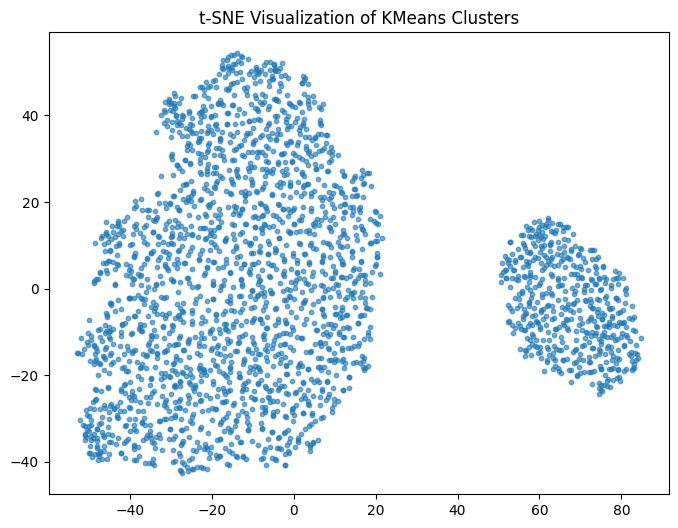

Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is not 1 tensor(0)
Q values where prob is no

<Figure size 640x480 with 0 Axes>

tensor([[0.9982, 0.7893, 0.9732, 0.9549, 0.9194, 0.9058, 0.8504, 0.8885, 0.9847,
         0.9739, 0.8455, 0.7159, 0.9085, 0.9421, 0.9371, 0.9114, 0.9804, 0.9983,
         1.0033, 0.9739, 0.9226, 0.9142, 0.9593, 0.9874, 0.9933, 0.7787, 0.9352,
         1.0149, 1.0184, 0.8440],
        [1.4576, 0.7614, 1.2558, 1.2097, 1.1496, 1.1278, 1.0356, 0.9745, 1.3510,
         1.2325, 1.0403, 0.6357, 1.0168, 1.2046, 1.2045, 1.1347, 1.3404, 1.4915,
         1.5003, 1.3127, 1.1122, 1.1423, 1.2827, 1.4154, 1.4729, 0.7469, 1.2130,
         1.5654, 1.5621, 1.0330]])
Training Complete!


In [15]:
features_ours, predictions_ours, cluster_centers_list_ours = trainer(model, dataloader, dec_starting_epoch=30, 
                                                      cluster_number=cluster_number,
                                                      exponent=2, epochs=70, use_wandb=False, 
                                                      log_likelihood_alpha=False,
                                                      use_diag_cov=True, learn_alpha=False, alpha=2)

In [16]:
from sklearn.manifold import TSNE

def visualize_clusters(features, predictions, cluster_centers):

    n = features.shape[0]
    perplexity = 30
    lr = n/12
    early_exaggeration=12
    print(features.shape)
    print(cluster_centers.shape)

    #plt.figure(figsize=(8,10), dpi=80)
    plt.figure(figsize=(8, 10))
    colors = plt.cm.get_cmap("tab10", cluster_number)  # Define colors for clusters
    color_map = {'C0', 'orange'}

    combined_data = np.vstack([features, cluster_centers])  # Stack features with centers

    # Apply t-SNE to combined data
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, early_exaggeration=early_exaggeration, random_state=42)
    embedded_data = tsne.fit_transform(combined_data)  # Run on combined data
    embedded_points = embedded_data[:n]  # First part corresponds to data points
    embedded_centers = embedded_data[n:]  # Last part corresponds to cluster centers

    for value in range(cluster_number):
        cluster_mask = predictions == value
        print(f"Cluster {value}: Mask shape = {cluster_mask.shape}, Points = {cluster_mask.sum()}")
        
        plt.scatter(
            embedded_points[cluster_mask, 0],
            embedded_points[cluster_mask, 1],
            label=f'Cluster {value+1}',
            alpha=0.7,
            s=10,
        )
        '''
        plt.scatter(
            embedded_centers[value][0],
            embedded_centers[value][1],
            c=[color_map[value]],  # Mapped color
            marker='X',
            s=100,
            edgecolor='black',
            label='Cluster Center'
        )
        '''
    #plt.title(f'clustered data')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Add legend automatically from the scatter plot
    plt.legend(fontsize=14, loc='upper right',  frameon=False)
    plt.xticks([])  # Remove x ticks
    plt.yticks([])  # Remove y ticks
    # Adjust layout and remove spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.show()

(2500, 30)
(2, 30)


/tmp/ipykernel_485624/793342735.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", cluster_number)  # Define colors for clusters


Cluster 0: Mask shape = (2500,), Points = 2000
Cluster 1: Mask shape = (2500,), Points = 500


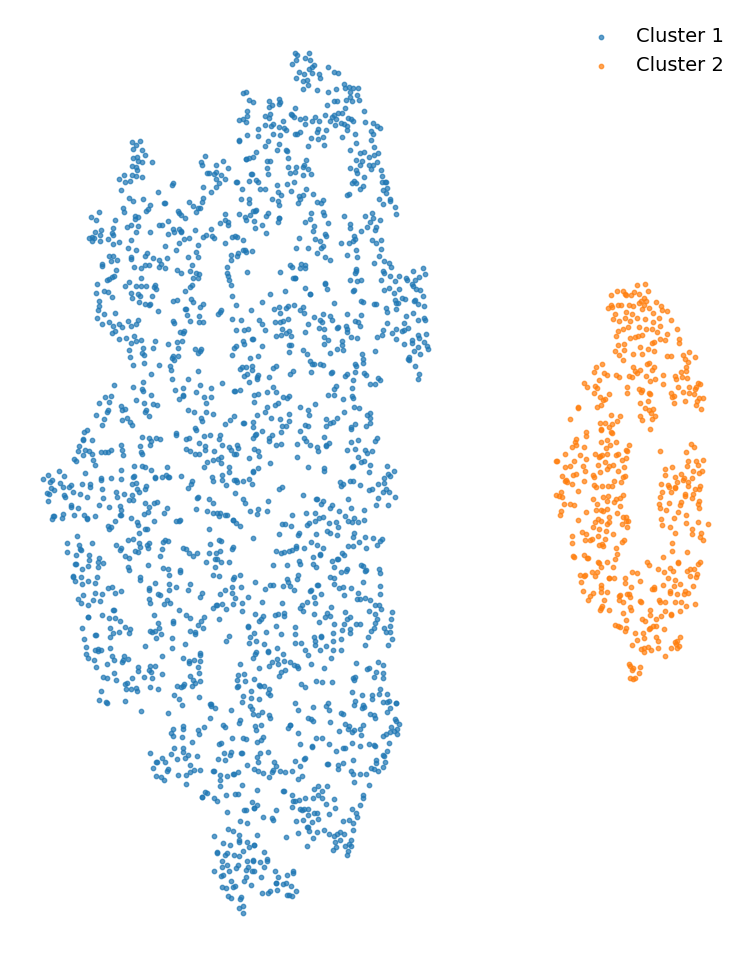

In [17]:
visualize_clusters(features_ours, predictions_ours, cluster_centers_list_ours[-1])

In [195]:
predictions_ours

array([1, 1, 1, ..., 0, 0, 0])

In [188]:
features_ours

array([[1.0032053 , 0.7961168 , 0.97823334, ..., 1.0143453 , 1.0174881 ,
        0.86897224],
       [1.003732  , 0.8489413 , 0.993668  , ..., 1.0123192 , 1.0105164 ,
        0.82152456],
       [1.0019872 , 0.7471483 , 0.97731084, ..., 1.0258914 , 1.0259154 ,
        0.7502637 ],
       ...,
       [1.4134334 , 0.6270706 , 1.1029696 , ..., 1.5816836 , 1.5567797 ,
        0.9947775 ],
       [1.4094949 , 0.6848052 , 1.1376172 , ..., 1.5619473 , 1.5410677 ,
        1.0885514 ],
       [1.4266034 , 0.6732633 , 1.1648316 , ..., 1.57845   , 1.584041  ,
        0.9188752 ]], dtype=float32)

In [189]:
features_DEC

array([[0.96388096, 0.5829096 , 0.8352193 , ..., 1.0093877 , 1.0028931 ,
        0.7875499 ],
       [0.9753782 , 0.6855008 , 0.8840425 , ..., 1.012142  , 1.0137159 ,
        0.8083923 ],
       [0.9789068 , 0.7271871 , 0.9220824 , ..., 1.0058458 , 1.0059379 ,
        0.83969325],
       ...,
       [1.4758439 , 0.79806626, 1.3616396 , ..., 1.4406353 , 1.4791645 ,
        1.0597157 ],
       [1.4302164 , 0.7266912 , 1.2810788 , ..., 1.4768043 , 1.5061119 ,
        1.0121205 ],
       [1.4216084 , 0.75902146, 1.252236  , ..., 1.488787  , 1.5090588 ,
        1.0686867 ]], dtype=float32)

(2500, 30)
(2, 30)


/tmp/ipykernel_3449415/4109202570.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", cluster_number)  # Define colors for clusters


Cluster 0: Mask shape = (2500,), Points = 2500
Cluster 1: Mask shape = (2500,), Points = 0


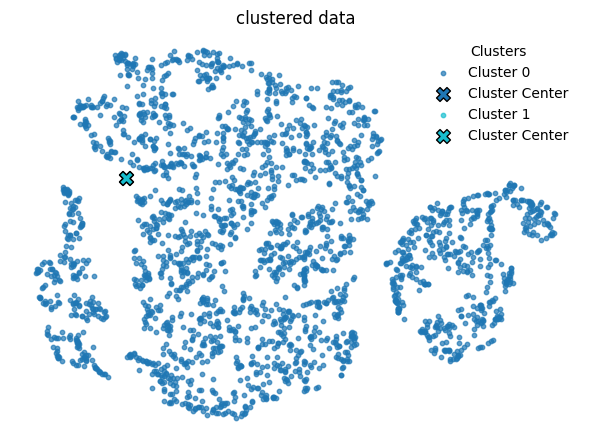

In [142]:
visualize_clusters(features_DEC, predictions_DEC, cluster_centers_list_DEC[-1])

In [143]:
def lambda_to_vector(f, input_dim=30, X_sample=None):
    """
    Converts a linear lambda function to a vector representation.
    Assumes form: lambda X, s: a * sum(X) + s
    """
    if X_sample is None:
        X_sample = np.ones((1, input_dim))
    
    # Evaluate f at all-ones and all-zeros
    y_ones = f(X_sample)[0]
    y_zeros = f(np.zeros_like(X_sample))[0]

    a = y_ones - y_zeros  # change per unit → gives sum of weights
    b = y_zeros           # constant shift

    w = np.ones(input_dim) * a / input_dim  # equally distributed
    return np.append(w, b)  # final vector [w..., b]

vector_functions = [lambda_to_vector(f) for f in functions]

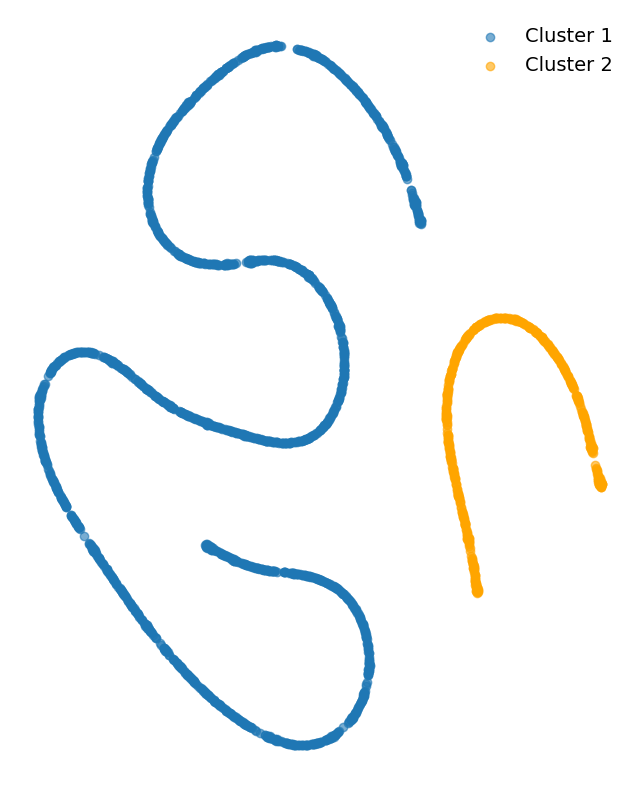

In [216]:
vector_functions = np.array(vector_functions)

n = vector_functions.shape[0]
perplexity = 30
lr = n/12
early_exaggeration=12

# Apply t-SNE to combined data
tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, early_exaggeration=early_exaggeration, random_state=42)
X_embedded = tsne.fit_transform(vector_functions)

# Create labels (first 2000 = 0, next 500 = 1)
labels = np.array([0]*2000 + [1]*500)

# Plot
plt.figure(figsize=(8, 10))
plt.scatter(X_embedded[labels == 0, 0], X_embedded[labels == 0, 1], label='Cluster 1', alpha=0.6, color= 'C0')
plt.scatter(X_embedded[labels == 1, 0], X_embedded[labels == 1, 1], label='Cluster 2', alpha=0.6, color='orange')
#plt.title("t-SNE of Function Vectors")
plt.legend(loc='upper right',  frameon=False, fontsize=14)
plt.xticks([])  # Remove x ticks
plt.yticks([])  # Remove y ticks
# Adjust layout and remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.show()

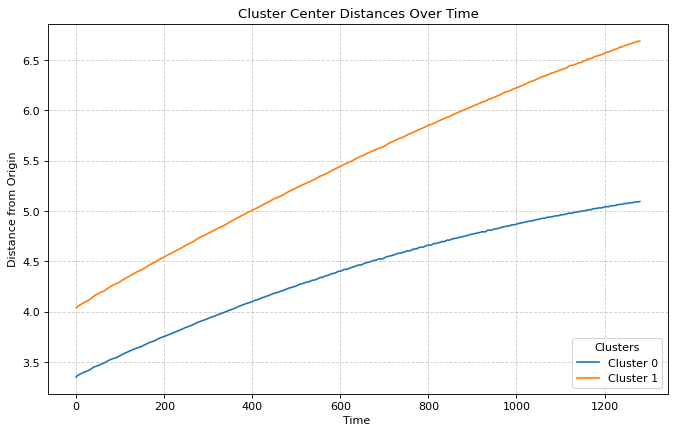

In [20]:
time = cluster_centers_list_ours.shape[0]
end_time =time
cluster_centers_distances=np.zeros((time, 2)) 

for batch in range(time):
    cluster_centers_distances[batch][:] = np.linalg.norm(cluster_centers_list_ours[batch],axis=1)

# Plot the distances of the cluster centers over time
plt.figure(figsize=(10, 6), dpi=80)


for cluster_idx in range(cluster_number):
    #if cluster_idx in unique_values:
    plt.plot(range(end_time), cluster_centers_distances[:end_time, cluster_idx], label=f'Cluster {cluster_idx}')

#plt.plot(range(end_time),kldiv_loss_batches[: end_time], label = 'kldiv_loss')
plt.xlabel('Time ')
plt.ylabel('Distance from Origin')
plt.title('Cluster Center Distances Over Time')
plt.legend(title='Clusters', loc='lower right', frameon=True)
plt.grid(True, linestyle='--',alpha=0.6)
plt.show()

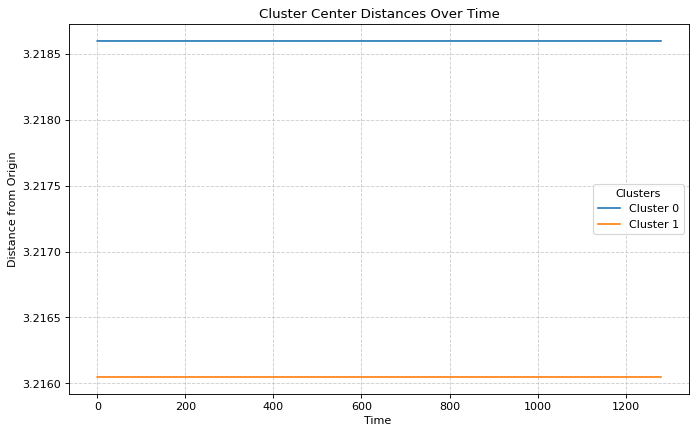

In [145]:
time = cluster_centers_list_DEC.shape[0]
end_time =time
cluster_centers_distances=np.zeros((time, 2)) 

for batch in range(time):
    cluster_centers_distances[batch][:] = np.linalg.norm(cluster_centers_list_DEC[batch],axis=1)

# Plot the distances of the cluster centers over time
plt.figure(figsize=(10, 6), dpi=80)


for cluster_idx in range(cluster_number):
    #if cluster_idx in unique_values:
    plt.plot(range(end_time), cluster_centers_distances[:end_time, cluster_idx], label=f'Cluster {cluster_idx}')

#plt.plot(range(end_time),kldiv_loss_batches[: end_time], label = 'kldiv_loss')
plt.xlabel('Time ')
plt.ylabel('Distance from Origin')
plt.title('Cluster Center Distances Over Time')
plt.legend(title='Clusters', loc='center right', frameon=True)
plt.grid(True, linestyle='--',alpha=0.6)
plt.show()

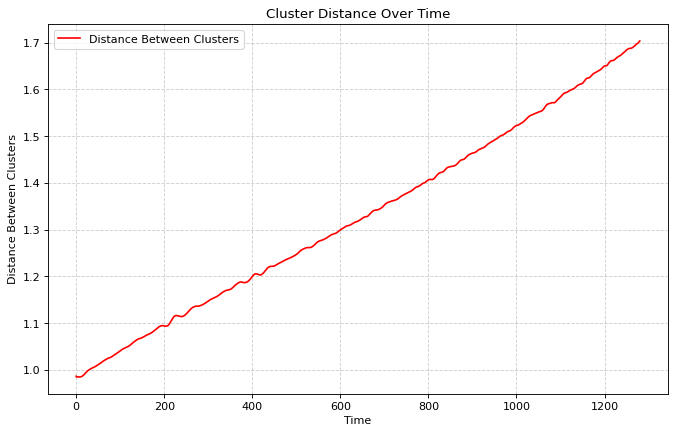

In [108]:
time = cluster_centers_list.shape[0]
cluster_distances = np.zeros(time)

# Compute the Euclidean distance between the two cluster centers at each timestep
for t in range(time):
    cluster_distances[t] = np.linalg.norm(cluster_centers_list[t, 0] - cluster_centers_list[t, 1])

# Plot the distance between the two clusters over time
plt.figure(figsize=(10, 6), dpi=80)
plt.plot(range(time), cluster_distances, label='Distance Between Clusters', color='r')

plt.xlabel('Time')
plt.ylabel('Distance Between Clusters')
plt.title('Cluster Distance Over Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()